# 3D Tomographic Reconstruction and Rotation Recovery of Gaussian Blobs with Oscillatory Motion Around a Principal Axis

This notebook provides a **comprehensive tutorial** on performing **3D tomographic reconstruction** from a sequence of 2D projections. It demonstrates the full workflow, from synthetic data generation to optimization-based recovery using **Gaussian blobs** as a well-controlled test object.

We simulate a 3D volume consisting of **Gaussian blobs** undergoing an **oscillatory rotation around a main axis**, mimicking realistic rotational motion observed in experimental tomography. From these volumes, we generate **forward projections** that represent our imaging measurements.

The objective is to recover both the **underlying 3D volume** and the **rotation parameters** using a combination of:

* A **Variational Autoencoder (VAE)** to learn compact latent representations and estimate initial rotation parameters.
* **Gradient-based optimization** to iteratively refine both the reconstructed volume and orientation estimates.

This notebook serves as a **reference implementation** — explaining each step in detail — and forms the foundation for simplified versions focused on specific imaging modalities or evaluation tasks.

---

### **Notebook Outline**

1. **Import Synthetic 3D Data**
   Create a volumetric object made of Gaussian blobs and define its oscillatory rotation pattern.

2. **Define Imaging Modality and Generate Projections**
   Simulate the imaging process (e.g., Brightfield microscopy) to obtain 2D projections from the rotating volume.

3. **Tomographic Reconstruction**
   Optimize both the 3D volume and the rotation parameters using gradient-based reconstruction with custom loss functions.

4. **Visualization and Evaluation**
   Compare the reconstructed volume and projections against the ground truth, and analyze quaternion trajectories to assess reconstruction quality.

5. **Saving and Exporting Results**
   Save the optimized volume and recovered rotation parameters for downstream use or further analysis.



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SkariZ/TomoDpDt/blob/main/Notebooks/sum_projection_vobble.ipynb)



In [1]:
# Uncomment if you run this notebook in Google Colab
#!pip install deeplay deeptrack plotly scipy opencv-python
#!git clone https://github.com/SkariZ/TomoDpDt.git
#import sys
#sys.path.append('/content/TomoDpDt')

In [2]:
# Uncomment if running this notebook locally
#import sys
#sys.path.append('..')

In [3]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time

import deeplay as dl
import torch
from torch.utils.data import DataLoader

In [4]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

[suppressed training logs: 19 chars]


## 1. Import 3D Volume Data

In this example, we load a 3D volume consisting of small Gaussian blobs placed randomly within the volume. The original volume is 64x64x64 voxels in size, but it can be upsampled or downsampled to any desired resolution.

In [5]:
volume = np.load('../test_data/vol_gauss_mult.npy')

In [6]:
print(f"Shape of the volume: {volume.shape}")

Shape of the volume: (64, 64, 64)


The volume has refractive index values in the range 1.33-1.42.

In [7]:
volume.max(), volume.min(), volume.mean(), volume.std()

(1.42, 1.33, 1.3304325754335748, 0.003685070733356758)

For optimization purposes it easier to work with the refractive index difference, assuming the sample is in water we can subtract 1.33.

In [8]:
volume = volume - 1.33

The 3D volume is stored in a `numpy` array and can be interactively visualized using the `ipyvolume` library together with `plotly`. Having it interactive and saving the `.ipynb` however make the file extremely large. Uncomment the code below for interactive plot.

In [9]:
# tomodpdt.plotting.visualize_3d_volume(volume)

Using sum projections along the x, y, and z axes, we can visualize the structure of the volume.

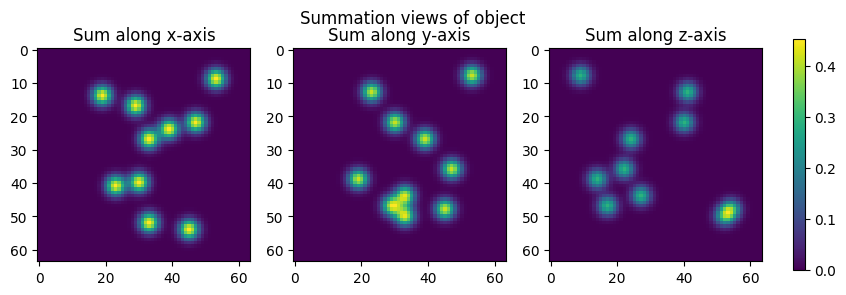

In [10]:
tomodpdt.plotting.plot_sum_object(volume)

## 2. Choosing the Imaging Modality

After defining or initializing the 3D volume, the next step is to **choose the imaging modality**.  
This determines how the 3D object is transformed into a 2D image, for example, whether you simulate **brightfield**, **fluorescence**, or another microscopy regime.

In practice, the imaging modality defines the *forward model* that links the 3D refractive-index or absorption volume to its measured intensity or phase image. By selecting the modality, you set the optical parameters that govern this transformation, such as numerical aperture (NA), wavelength, and resolution.

Below, we import the functions that configure and construct the imaging model.  
First, `setup_optics()` creates an object containing all relevant optical parameters, and then `imaging_model()` builds a differentiable model based on those settings.

```python

In [11]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# --- Setup the optical system ---
optics_settings = setup_optics(
    shape=volume.shape,       # Shape of the 3D volume
    padding_xy=volume.shape[0]//2,  # Padding in the lateral directions (avoids wrap-around effects)
    microscopy_regime='Brightfield', # Choose microscopy type: 'Brightfield', 'Fluorescence', etc.
    NA=1.1,                      # Numerical Aperture of the objective
    wavelength=520e-9,           # Illumination wavelength in meters
    resolution=200e-9,           # Effective pixel resolution in meters
    magnification=1,             # System magnification
    return_field=True            # Return the complex optical field instead of intensity only
)

# --- Build the imaging model ---
brightfield_model = imaging_model(optics_setup=optics_settings)


### 2.1 Generating Training Data

In this step, we generate the dataset that will be used to **optimize and recover the 3D refractive index distribution** of the sample.  
Since we are working with **Brightfield microscopy**, the projections correspond to **intensity-based images** that result from integrating the transmitted light through the volume.  These simulated measurements serve as our training data for the tomographic reconstruction process.

The data generation process is handled by a helper function that allows you to customize several parameters:

- **`rotation_case`** — Specifies the type of rotational motion used when generating projections.  
  - In this example, we use `'random_sinosoidal'`, which means the object is rotated following a sinusoidal pattern, and the rotation axis is chosen randomly for each sequence.
- **`samples`** — Number of projections (data samples) to generate.  
- **`duration`** — Number of full rotations to perform during data generation.

The function returns:

- **`test_object`** — The simulated 3D object being projected  
- **`quaternions`** — The ground-truth rotation parameters for each projection  
- **`projections`** — The 2D Brightfield-like projections generated from the volume  
- **`imaging_model`** — The imaging model used (`brightfield_model` in this example)

In [ ]:
test_object, q_gt, projections, imaging_model = tomodpdt.simulate.create_data(
    volume=volume, # The volume we want to reconstruct
    image_modality=brightfield_model, # We use our brightfield imaging model
    rotation_case='random_sinusoidal', # We rotate the object around 1 main axis, but the other 2 axes are also non-zero an
    samples=250, # Number of projections
    duration=2 # Duration is the number of full revolutions
    )

[suppressed training logs: 20 chars]


As a quick sanity check, we can inspect the shapes of the generated components to ensure everything looks correct:

-  **3D Object Shape** — Represents the volume of the object
-  **Rotation Parameters (Quaternions)** — Ground truth rotations applied to the object
-  **Projections** — Forward projections of the object along the z-axis
-  **Imaging Model** — The imaging modality used for the projections


These shapes should match your expectations based on the number of samples and the structure of the input volume.

In [13]:
print(f"Shape of the test_object: {test_object.shape}")
print(f"Shape of the q_gt: {q_gt.shape}")
print(f"Shape of the projections: {projections.shape}")
print(f"Type of imaging_model: {type(imaging_model)}")

Shape of the test_object: torch.Size([64, 64, 64])
Shape of the q_gt: torch.Size([250, 4])
Shape of the projections: torch.Size([250, 2, 64, 64])
Type of imaging_model: <class 'tomodpdt.imaging_modality_torch.imaging_model'>


### 2.2 Visualizing the Training Data

In this section, we explore the generated training data through the forward images and the corresponding rotation parameters.

#### Projection of the 3D Object

To gain an intuitive understanding of the simulated data, we perform a **forward pass** using the **Brightfield imaging model** defined earlier. This step computes how the 3D refractive index distribution would appear when imaged under Brightfield illumination — essentially, how light transmitted through the object forms a 2D intensity image on the detector.

Each projection corresponds to a unique orientation of the object, determined by its associated rotation parameters.  
By visualizing a random **3×3 grid**

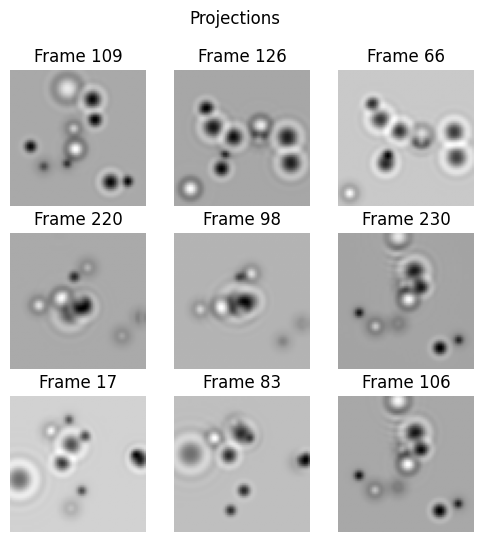

In [14]:
tomodpdt.plotting.plot_grid33_frames(projections, title="Projections", randomize=True)

#### Visualizing the Quaternion Trajectory

Now that we’ve explored a sample of the simulated projections, we can examine the **rotation parameters** that define how each projection was generated.

Each projection corresponds to a specific **3D rotation** applied to the volume, and this rotation is represented as a **quaternion** — a compact, four-dimensional vector that encodes orientation in 3D space.

---

##### What Are Quaternions?

Quaternions are widely used in 3D graphics, robotics, and computer vision to represent rotations.  
They provide several advantages over other representations such as Euler angles or rotation matrices:

- **No gimbal lock:** Quaternions avoid the singularities that occur with Euler angles.  
- **Smooth interpolation:** They allow for continuous and stable interpolation between orientations (known as *slerp*).  
- **Compact representation:** Only four components $[q_w, q_x, q_y, q_z]$ are required to describe a rotation.

In our dataset, each quaternion defines the **exact orientation** of the object used to generate a corresponding projection.  
For example, if we have 400 projections, then there are 400 associated quaternions — each one describing a unique rotation applied to the 3D volume during the Brightfield simulation.


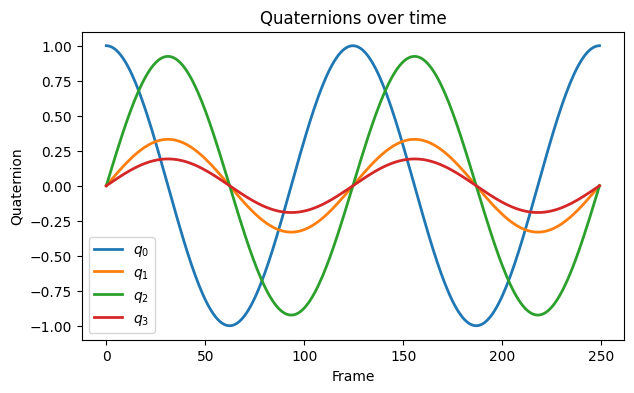

In [15]:
tomodpdt.plotting.plot_quaternions(q_gt)

## 3. Tomographic Reconstruction

In this section, we focus on **tomographic reconstruction**, that is, the process of recovering a 3D volume from a set of 2D projection images acquired under different viewing angles.

---

### **What Is Tomography?**

Tomography is based on the principle that a 3D object can be reconstructed if we know its **2D projections** from sufficiently many orientations.  
Each projection corresponds to an integral (or optical transform) of the 3D object along a specific direction, typically described by a rotation matrix or quaternion.

Formally, if $ V(x, y, z) $ is the 3D refractive index distribution, and $ P_\theta(x, y) $ is its 2D projection at orientation $ \theta $, then:

$$
P_\theta(x, y) = \int V(R_\theta [x, y, z]^T)\,dz
$$

where $ R_\theta $ is the 3D rotation operator corresponding to angle $ \theta $.  
In other words, tomography aims to **invert** this projection process — recovering $ V $ from the measured projections $ P_\theta $.

For this inversion, it is *sufficient* to know:
1. The 2D projections themselves, and  
2. The rotation parameters (or equivalently, their quaternions).  

Given these two pieces of information, we can theoretically reconstruct the full 3D structure of the object.

---

### **Overview of the Reconstruction Approach**

In this notebook, we use a differentiable, learning-based reconstruction framework implemented in the `Tomography` class.  
Rather than using analytical inversion (like filtered backprojection), we formulate tomography as an **optimization problem** and solve it with **Stochastic Gradient Descent (SGD)**.

The process is divided into two main stages:

---

#### **Step 1: Estimate Initial Rotation Parameters**

1. A **Variational Autoencoder (VAE)** is first trained on the 2D projections to learn a compact latent representation of the data.  
2. Using this learned latent space, the method estimates the **initial rotation parameters** (represented as quaternions) that best correspond to each projection’s orientation.  
   - This step provides an approximate alignment of the data before full reconstruction.

---

#### **Step 2: Joint Optimization of the 3D Volume and Rotations**

Once initial rotations are estimated, the reconstruction proceeds by **jointly optimizing** both:
- the **3D refractive index volume**, and  
- the **rotation (and translation) parameters**.

This is achieved by minimizing a **composite loss function** within the `Tomography` class, which combines multiple physically and geometrically motivated terms:

| **Loss Term** | **Description** |
|:--|:--|
| **Projection Loss (Proj loss)** | Measures the difference between measured 2D images and simulated projections from the current 3D volume. |
| **Latent Loss** | Compares latent-space embeddings of measured and simulated projections (VAE consistency). |
| **Total Variation Loss (Rtv loss)** | Regularizes the 3D volume, encouraging smoothness and spatial continuity. |
| **Quaternion Validity Loss (Qv loss)** | Ensures all rotation parameters remain valid unit quaternions ($ \|q\| = 1 $). |
| **Initial Quaternion Loss (Q0 loss)** | Constrains the first quaternion to represent the identity rotation $[1, 0, 0, 0]$. |
| **Rotation Smoothness Loss (Rtr loss)** | Promotes temporal smoothness of rotation trajectories across successive frames. |
| **Strictly Over Loss (So loss)** | Enforces physical constraints on the refractive index (e.g., values > 1.0 for transparent materials). |

---

### **Mathematical Perspective**

We can express the optimization as:

$$
\min_{V, q} \; \mathcal{L}_{\text{proj}} + \lambda_1 \mathcal{L}_{\text{latent}} + \lambda_2 \mathcal{L}_{\text{TV}} + \lambda_3 \mathcal{L}_{\text{rot}}
$$

subject to $ \|q_i\| = 1 $ for all rotation quaternions $ q_i $.

Here, the goal is to find both the 3D volume $ V $ and the orientations $ q $ that best explain the measured projections under the chosen imaging model (in this case, **Brightfield**).

---

### **Implementation Notes**

- The reconstruction pipeline is implemented via the custom **`Tomography`** class, which integrates the forward model, loss computation, and optimization routine.  
- The **forward operator** is defined by the `imaging_model` (e.g., Brightfield optics), ensuring that the reconstruction remains physically consistent with the imaging process.  
- All optimization is performed in PyTorch, allowing gradients to flow through the projection operator and the volume.  

This differentiable framework bridges traditional tomography and modern deep learning, enabling robust, data-driven reconstruction even when rotation parameters are uncertain or noisy.



### 3.1 Setting Up the Tomographic Reconstruction Class

The **`Tomography`** class is the core component that orchestrates the entire 3D reconstruction process.  
It builds on `deeplay.Application`, allowing for a modular and extensible framework that integrates training, optimization, and inference in one place.

This class encapsulates everything required for tomographic reconstruction — from initializing the 3D volume and learning rotation parameters, to running the optimization loop and managing the various loss components.

---

#### **Key Parameters**

Below are some of the most relevant parameters to understand and customize before training:

- **`volume_size`** — Defines the resolution of the 3D reconstruction volume, typically cubic (e.g., `(96, 96, 96)`).  
  A higher resolution increases reconstruction fidelity but also the computational load.

- **`initial_volume`** — Sets the initial estimate for the 3D volume.  
  For **Brightfield microscopy**, this is often initialized as `'refraction'`, which corresponds to a uniform refractive index (≈ 1.33).  
  Other options include:
  - `'zeros'` – starts from an empty volume  
  - `'gaussian'` – a smooth blob-shaped initialization  
  - `'random'` – randomized voxel values  
  - `'given'` – supply your own tensor as a starting point

- **`rotation_optim_case`** — Determines how the orientation of each 2D projection is represented and optimized:  
  - `'quaternion'` — direct optimization in quaternion space, ideal for fine-grained control  
  - `'basis'` — uses a smoother, low-dimensional basis representation, helpful when orientations vary gradually

- **`imaging_model`** — The optical forward model that defines how the 3D volume is projected into 2D images (e.g., **Brightfield**, **Fluorescence**, etc.).

In [16]:
# Create the tomographic_model
tomographic_model = tomodpdt.Tomography(
    volume_size=volume.shape, # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='basis', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model
    )

#### **Customizing the Optimization Losses**

The optimization process in tomography combines multiple physical and mathematical constraints through **loss weights**.  
Each component of the loss contributes to different aspects of the reconstruction (e.g., projection matching, smoothness, rotation consistency, etc.).

You can easily customize the relative importance of each term by passing your own dictionary to the class:

```python
# Example: custom loss weighting for your specific problem
custom_loss_weights = {
    'proj_loss': 5.0,    # Emphasize accurate 2D projection matching
    'latent_loss': 0.2,  # Encourage consistent latent representations
    'rtv_loss': 4.0,     # Smoothness regularization on the 3D volume
    'qv_loss': 0.1,      # Ensure quaternion normalization
    'q0_loss': 0.05,     # Keep first rotation near identity
    'rtr_loss': 2.0,     # Smooth rotation trajectory
    'so_loss': 50.0,     # Enforce physical constraints (e.g., refractive index > 0)
}

# Initialize the tomography class with custom settings
tomography = Tomography(
    volume_size=(96, 96, 96),
    initial_volume='refraction',
    rotation_optim_case='basis',
    imaging_model=brightfield_model,
    loss_weights=custom_loss_weights
)

### 3.2 Initializing the Rotation Parameters

Before the optimization process begins, we need a good **initial estimate of the rotation parameters** — i.e., how each 2D projection corresponds to an orientation of the 3D object.  
Accurate initialization is crucial: without it, the reconstruction might converge to a poor local minimum or fail to align the projections properly.

---

#### **Using a Variational Autoencoder (VAE) for Initialization**

The initialization is handled through the method:

```python
tomography.initialize_parameters(projections)
````

This method internally trains a **Variational Autoencoder (VAE)** on the 2D projections.
The goal of the VAE is to learn a **compact latent representation** of the images — a 2D or low-dimensional space where similar projections (i.e., those captured from similar orientations) are placed close together.

Once trained, the encoder’s output (the latent space) reflects the geometry of the underlying rotation manifold.
By analyzing this structure, we can infer the **relative orientations** of each projection.

---

#### **From Latent Space to Rotations**

To extract rotation estimates from the learned latent space, we analyze the distribution of encoded points:

1. **Latent Embedding:**
   Each projection is passed through the VAE encoder to obtain its latent coordinates.

2. **Peak Detection:**
   We identify peaks or clusters in this latent distribution — each representing a consistent rotational region.
   This is achieved using `scipy.signal.find_peaks`, which detects local maxima in the latent trajectories.

3. **Quaternion / Basis Initialization:**
   From these peak locations, the method computes an initial guess for the **rotation parameters**:

   * If `rotation_optim_case='quaternion'`, the parameters are represented as unit quaternions.
   * If `'basis'`, the rotations are expressed as coefficients of smooth basis functions for continuous motion.

---

#### **Why This Matters**

This VAE-based approach provides a **data-driven initialization** of the orientations — without requiring any prior information about how the object was rotated.
The estimated quaternions or basis coefficients form a coherent starting point for the subsequent optimization of both the **3D volume** and **rotation parameters**.

> **Tip:**
> If the peaks in latent space are not detected correctly (e.g., due to noise or too few projections), you can fine-tune the parameters in `find_peaks` such as `prominence`, `distance`, or `height` to improve stability.

---

Once the parameters are initialized, the `Tomography` object is ready to begin the joint optimization stage — refining both the **3D structure** and the **rotational trajectory**.


In [17]:
# Initialize the parameters
tomographic_model.initialize_parameters(projections, normalize=False, max_epochs=200)

[suppressed training logs: 1,784 chars]
---------------------------------------------------------------------
---------------------------------------------------------------------
258 K     Trainable params
0         Non-trainable params
258 K     Total params
1.032     Total estimated model params size (MB)
77        Modules in train mode
0         Modules in eval mode


[suppressed training logs: 618 chars]
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


[suppressed training logs: 256 chars]


Rotation initialization from latent space successful.


For vizualisation we initialize a `TomoPlotter` class for easier plotting.

In [18]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

### Visualizing the Latent Space Trajectory

Using the trained **Variational Autoencoder (VAE)**, we can visualize how the **latent space** evolves over time.  
Each point in this space corresponds to a single 2D projection, and together they form a **trajectory** that reflects the underlying dynamics of the system.

In a well-trained model, **rotational motion** of the object manifests as a smooth, often cyclic path through the latent space — showing how the VAE internally encodes changes in orientation.

If such cyclic behavior is **not observed**, it often indicates that the VAE has not converged optimally.  
Common causes include:
- An imbalance between the **reconstruction loss** and **KL-divergence loss** (e.g., a too-large `β` value),
- Insufficient training epochs, or
- A mismatch between the latent dimensionality and the complexity of the rotation manifold.

> 💡 **Tip:**  
> When tuning your VAE, try adjusting the loss weighting between the reconstruction and KL terms.  
> A more balanced latent trajectory typically leads to more reliable rotation initialization downstream.


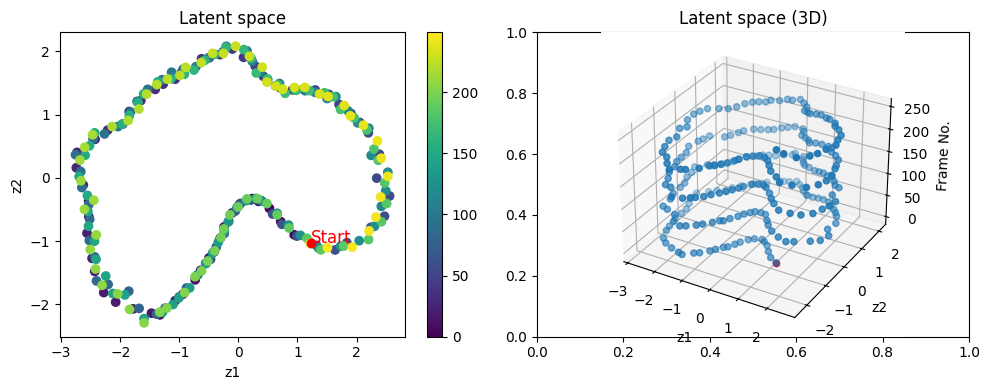

In [19]:
plotter.plot_latent_space()

### Estimating the Rotation Trajectory

To interpret the learned latent trajectory in terms of physical rotation, we compute the **Euclidean distance** between each latent point and the **starting point** of the sequence.  
This distance evolves smoothly over time — and **peaks** in this signal correspond to **complete revolutions** of the object.

By analyzing these periodic peaks, we can estimate:
- The **number of rotations** performed during the acquisition, and  
- The **dominant rotation axis**, assuming the remaining two axes are initially zero.

This provides a strong **initial estimate** for the rotation parameters, serving as a solid starting point for the optimization procedure that follows.

However, it’s important to note that this step can sometimes be **sensitive to errors** — since the peak detection relies on `scipy.signal.find_peaks`, which depends on several hyperparameters such as **threshold**, **prominence**, and **window size**.  
If peaks are missed or detected inconsistently, the initialization may require manual tuning or repeated estimation with adjusted parameters.

> 💡 **Tip:**  
> If you notice irregular spacing between peaks or unstable orientation estimates, try adjusting the `find_peaks` parameters or smoothing the latent trajectory before analysis.


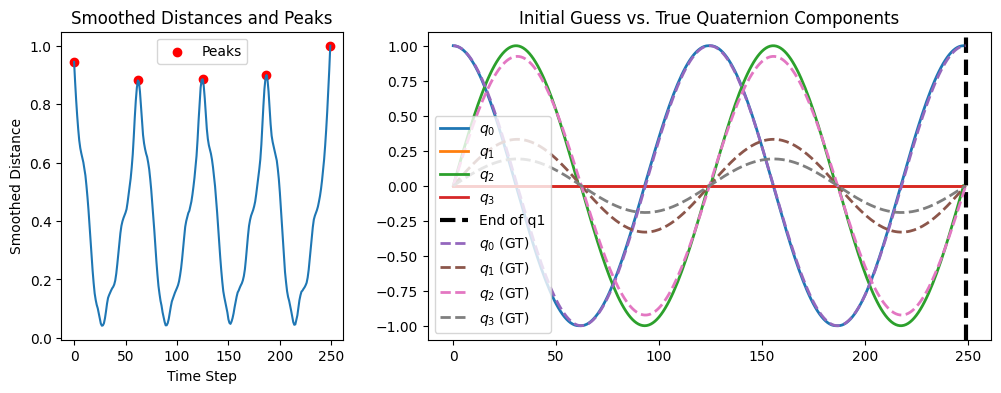

In [20]:
plotter.plot_smooth_dist_intial_guess(q_gt=q_gt)

To further validate the performance of the **Variational Autoencoder (VAE)**, we compare the **reconstructed frames** to their **original inputs**.  
A well-trained VAE should reproduce projections that are **visually similar** to the originals — capturing the key structural and contrast features of the object.

While **perfect pixel-wise reconstruction** is not required, what matters most is that the **overall shape and spatial distribution** of the object are preserved. This ensures that the learned latent space meaningfully represents the rotational variations, which is essential for accurate initialization of the tomographic reconstruction.

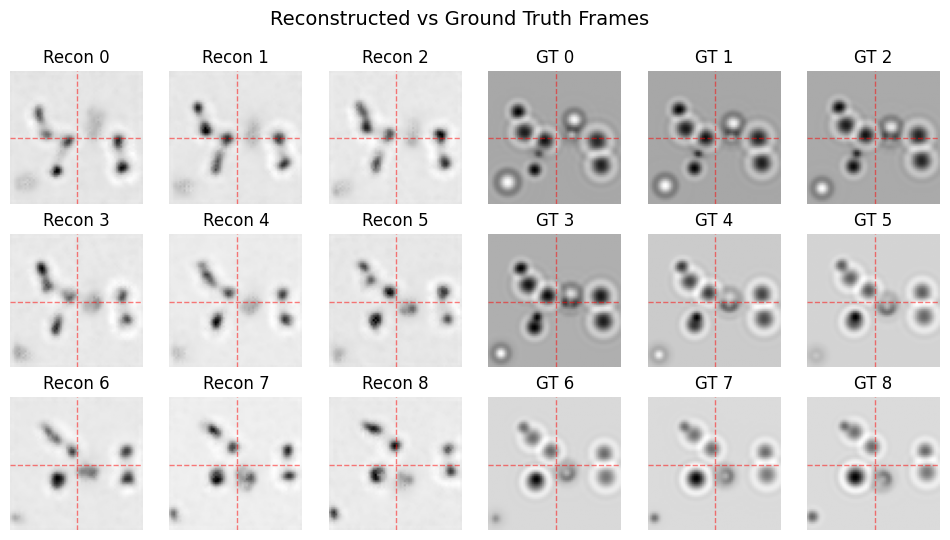

In [21]:
plotter.plot_reconstructed_vs_gt()


### 3.3 Starting the 3D Reconstruction Optimization

As outlined in the main section, we now proceed with the **3D reconstruction optimization** — the core step where the tomographic model jointly refines both the **3D volume** and the **rotation parameters** to best explain the observed 2D projections.

The optimization typically begins by focusing on the **volume** alone.  
This staged approach helps the model establish a stable representation of the object before adjusting the more sensitive rotational and translational parameters.

In the `Tomography` application, this is managed automatically:  
the optimizer first updates the **volume** for a few initial steps, and then gradually includes the **rotation** and **translation** parameters in the gradient updates.  
Alternatively, you can control this behavior manually by toggling parameter gradients using methods such as:

```python
tomography.toggle_gradients_volume(True)
tomography.toggle_gradients_rotation_translation(False)

or

tomography.toggle_gradients_quaternion(False)
tomography.toggle_gradients_translation(False)

````

This allows for a flexible optimization schedule — first refining the 3D structure, and then unlocking the motion parameters once the model has stabilized.

While it is possible to provide a **custom initial volume** (for instance, a precomputed estimate or a prior), in this example we start from a **uniform refractive index volume** of **1.33**, corresponding to the `'refraction'` initialization mode.

> 💡 **Tip:**
> This two-phase optimization strategy (volume-first, then joint) often leads to faster convergence and improved stability, especially in Brightfield tomography where rotation gradients can initially be unstable.



In [22]:
N1 = len(tomographic_model.frames) # Number of frames
idx = torch.arange(N1) # List of indexes
epochs_object_only = 50 # Number of epochs for the object only optimization
batch_size_object_only = 32 # Batch size for the object only optimization

In [23]:
# Toggle the gradients of the quaternion parameters to False
tomographic_model.toggle_gradients_quaternion(False)

# Toggle the gradients of the translation parameters to False
tomographic_model.toggle_gradients_translation(False)

# Move the model to device and all parameters
tomographic_model.move_all_to_device(DEV)

Below, we train the model for **`epochs_object_only`** epochs.  
The training loop is managed by the standard **deeplay Trainer**, which handles batching, logging, and device management automatically.

Since `deeplay.Trainer` is built on top of **PyTorch Lightning**, it inherits all of its advanced training functionalities, including checkpointing, mixed precision, GPU/TPU acceleration, and efficient logging — while maintaining a clean and modular workflow.

[suppressed training logs: 926 chars]
-----------------------------------------------------------------
-----------------------------------------------------------------
262 K     Trainable params
258 K     Non-trainable params
520 K     Total params
2.084     Total estimated model params size (MB)
83        Modules in train mode
0         Modules in eval mode


[suppressed training logs: 294 chars]


[suppressed training logs: 256 chars]


[suppressed training logs: 45 chars]


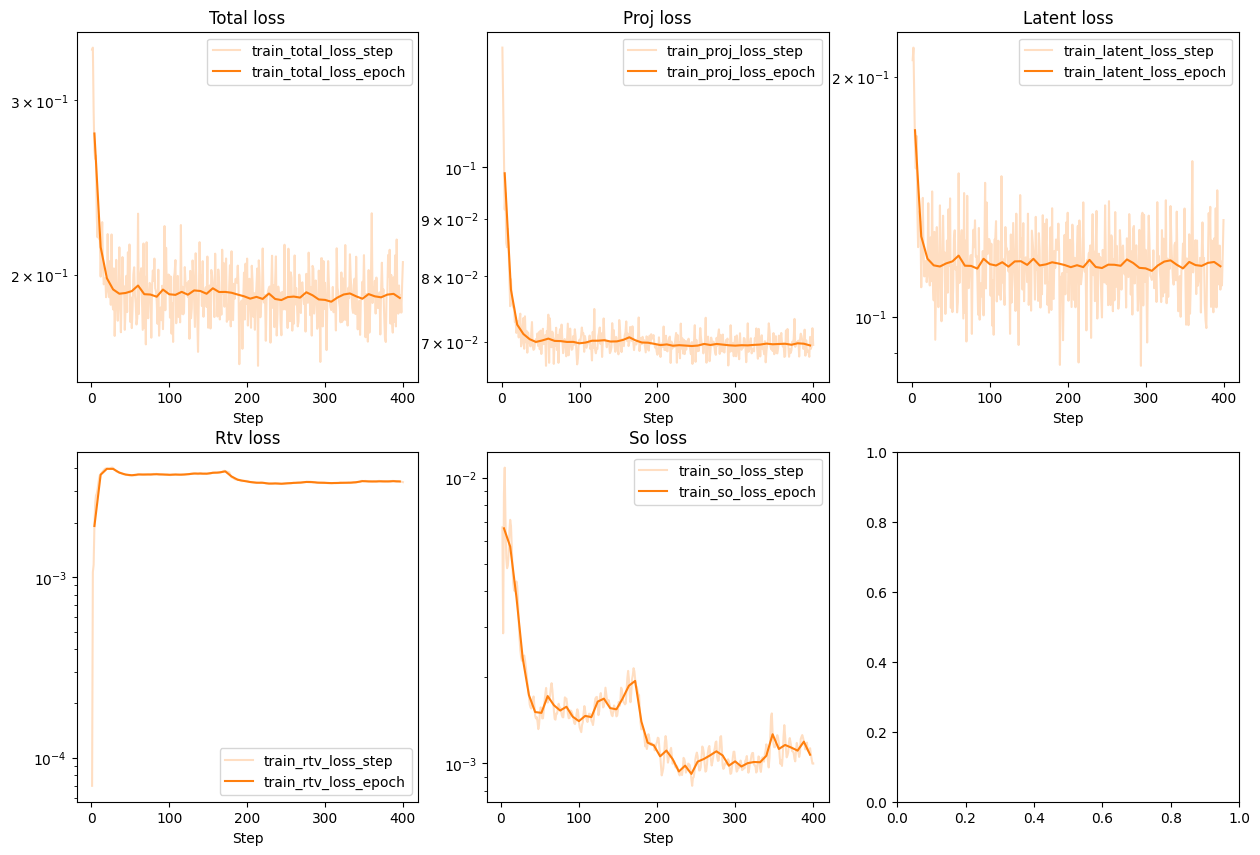

In [24]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_only, accelerator="auto", log_every_n_steps=10)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

### 3.4 Optimize the 3D volume and the rotation parameters

This is the main optimization loop, where both the 3D volume and rotation parameters are optimized simultaneously. It mirrors the earlier procedure, but now gradients for the rotation parameters are enabled.

In [25]:
epochs_object_rot = 250 # Number of epochs for the object and rotation optimization
batch_size_object_rot = 32 # Batch size for the object and rotation optimization

In [26]:
# Toggle the gradients of the quaternion parameters
tomographic_model.toggle_gradients_quaternion(True)

# The gradients of the translation parameters are already False and remain so since we do not want to optimize them now
# tomographic_model.toggle_gradients_translation(False)

# Move the model to device
tomographic_model.move_all_to_device(DEV)

and train the model for `epochs_object_rot` epochs...

[suppressed training logs: 926 chars]
-----------------------------------------------------------------
-----------------------------------------------------------------
262 K     Trainable params
258 K     Non-trainable params
520 K     Total params
2.084     Total estimated model params size (MB)
83        Modules in train mode
0         Modules in eval mode


[suppressed training logs: 256 chars]


[suppressed training logs: 45 chars]


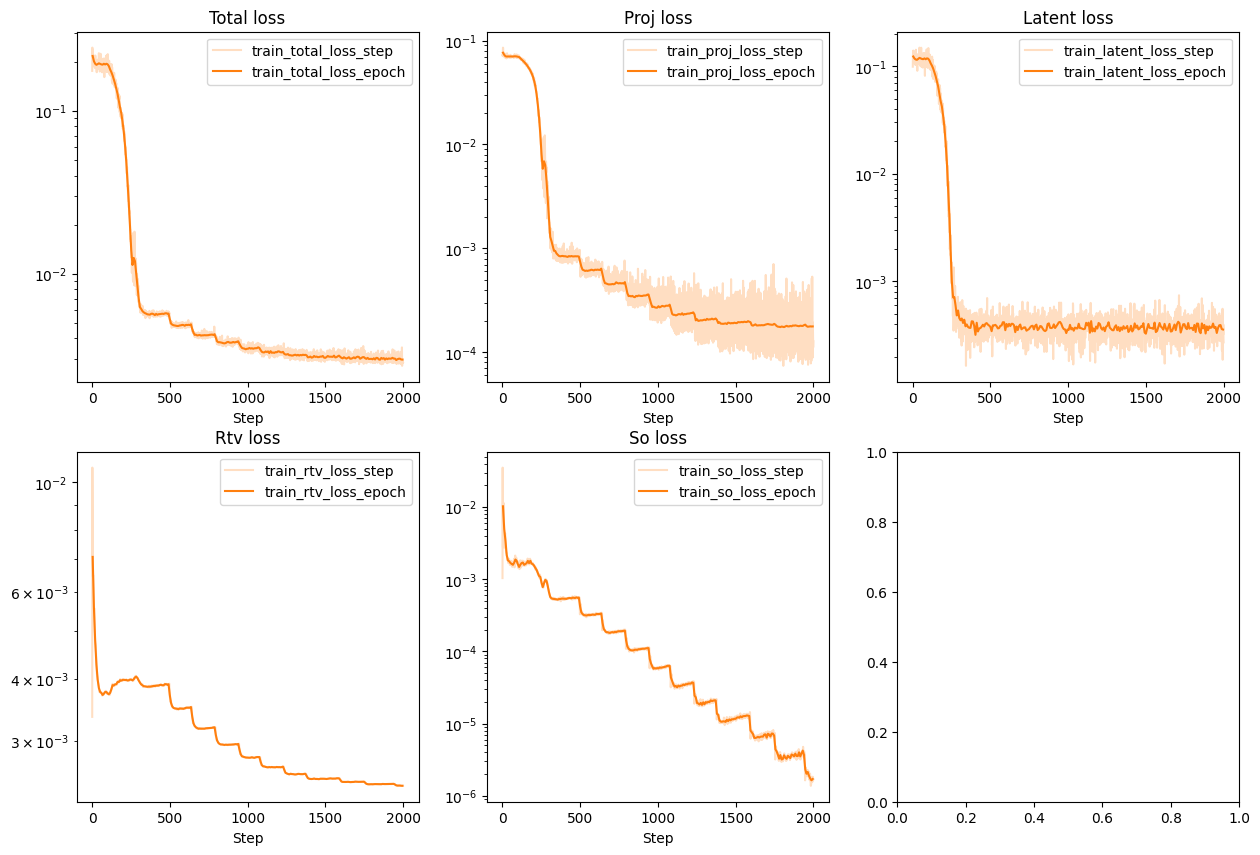

In [27]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_rot, accelerator="auto", log_every_n_steps=None)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_rot , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

## 4. Visualizing the Reconstructed Volume and Rotation Parameters

After training, we can now visualize the **reconstructed 3D volume** and the corresponding **rotation parameters** to assess the quality of the reconstruction.

- The **reconstructed volume** is displayed as a 3D visualization (e.g., an isosurface, volume rendering, or orthogonal slices), providing an intuitive view of the recovered object structure.  
- The **rotation parameters** are shown as a 3D scatter plot in quaternion space (or as Euler angles), illustrating how the orientations evolve over time and how well they capture the rotational trajectory of the data.

Together, these visualizations help confirm that the reconstruction pipeline has correctly recovered both the **internal 3D structure** and the **motion geometry** of the system.


In [28]:
# Move it to the GPU if possible for faster plotting
tomographic_model.move_all_to_device(DEV)

# Visualize the final volume and rotations.
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

By visualizing summation views of the 3D object along the x, y, and z axes, we can assess how well the optimized volume matches the ground truth.

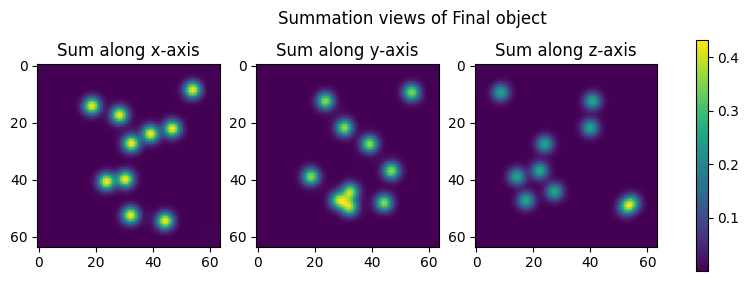

In [29]:
plotter.plot_sum_object(save_name="Final object")
plotter.plot_sum_object(obj=test_object.cpu(), save_name="Ground truth object")

Rather than showing simple summation views, we visualize the forward projections of the reconstructed volume and compare them to the ground truth 2D frames. A strong similarity between the two indicates that the 3D reconstruction and estimated rotations accurately reproduce the observed data.

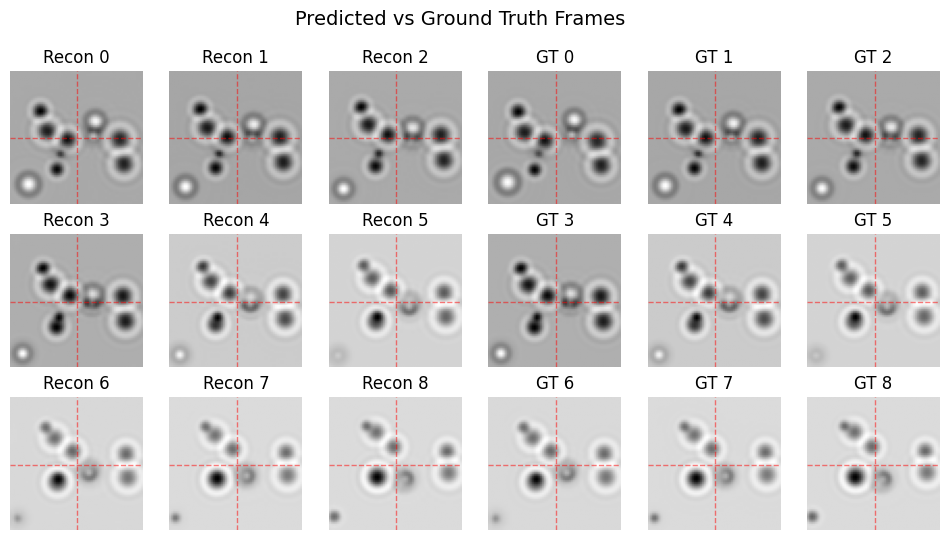

In [30]:
plotter.plot_reconstructed_vs_gt(column_headers=["Predicted", "Ground Truth"], forward=True, save_name="Reconstructed vs GT")

We can visualize the optimized quaternions and observe that they closely match the ground truth, demonstrating that the optimization successfully recovered the object’s rotational dynamics.

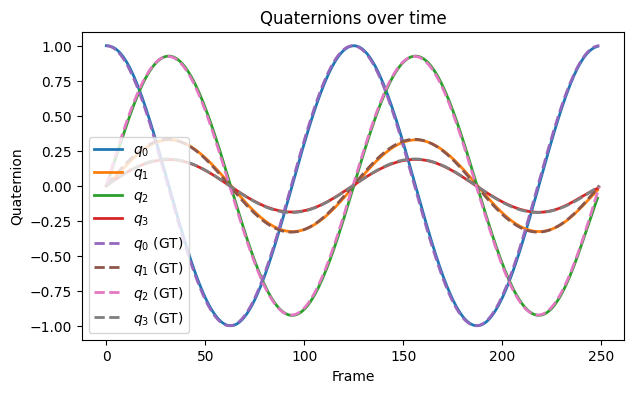

In [31]:
plotter.plot_quaternions(q_gt=q_gt)

The most effective way to visualize and compare the reconstructed volume to the ground truth is through interactive 3D plots using `plotly`.

In [32]:
# Uncomment belowto visualize the 3D volume
# tomodpdt.plotting.visualize_3d_volume(tomographic_model.volume.detach().cpu(), save_name="Final object 3D")
# tomodpdt.plotting.visualize_3d_volume(test_object.cpu(), save_name="Ground truth object 3D")

## 5. Save the reconstructed volume and the parameters

Once the process is complete, we can save the reconstructed volume and the quaternion parameters to `numpy` arrays.

In [33]:
# Define where to save the reconstruction results
# save_folder = "path/to/save/folder"

# --- Save the reconstructed 3D volume ---
# Extract the optimized volume from the model and save as a NumPy array
# volume = tomographic_model.get_volume().detach().cpu().numpy()
# np.save(f"{save_folder}/volume.npy", volume)

# --- Save the optimized quaternions ---
# Extract the final quaternion parameters and save them as a NumPy array
# quaternions_pred = tomographic_model.get_quaternions_final().detach().cpu().numpy()
# np.save(f"{save_folder}/quaternions.npy", quaternions_pred)

